# SVC Grid Search — Corrected Range (`svc_grid_search_test.ipynb`)

**Self-contained side-experiment.** It does **not** modify `hack2.ipynb`, and it only ever writes
`submission_svcgrid.csv` — never the existing `submission.csv`.

## The specific reason to look again at SVC

SVC-RBF is the member that broke the stage-2/3 ceiling, and our current best uses
`SVC(C=20, gamma=0.01)` (stack CV ~0.8345 ± 0.0071, **Kaggle 0.84552**). The *wider* search that
found `gamma=0.01` had it sitting at the **edge** of its grid — and when an optimum lands on the
boundary, the true best often lies **just past it**. We never searched **below** 0.01. This
notebook does exactly that.

## Why the grid is designed this way (this matters)

- **`gamma` controls boundary curvature.** Our data clearly wants **small** gamma (the winner was
  0.01). Large gamma (≥ 1) makes the kernel hug individual training points → **severe overfitting**
  (great train score, useless on test). So we **exclude `gamma ≥ 1`** and instead extend
  **downward** — `0.0003, 0.001, 0.003` — to probe the unexplored region *below* the current best.
- We also cap `C` at 100 (drop `C ≥ 1000`): very large `C` removes regularization and overfits too.
- **CRITICAL:** `GridSearchCV` defaults to **accuracy**. We pass **`scoring="f1_macro"`** — selecting
  SVC by accuracy instead of the competition metric is the exact mistake we refuse to make.

## Facts
- `train.csv` (9,000; fallback `tran.csv`), `final-check.csv` (5,000). Target `sleep_stage`
  (4 classes). Metric **macro-F1**. `id` → drop from features, keep for submission.
- Features = 21 + `eog_burst_index_missing` flag (from raw NaNs). `StratifiedKFold(5, shuffle, rs=42)`.
- SVC pipeline: `SimpleImputer(median) → StandardScaler → SVC(rbf, probability=True, rs=42)`.
- References: current-best stack (SVC C=20, γ=0.01) ~0.8345 ± 0.0071; champion default-SVC stack
  0.8308 ± 0.0052; default solo SVC 0.8296.

## 1. Setup

In [1]:
# Installs if needed:
# %pip install catboost xgboost
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 42
TARGET = "sleep_stage"
FLAG_COL = "eog_burst_index_missing"

def _load_first_existing(candidates):
    for name in candidates:
        if os.path.exists(name):
            return pd.read_csv(name), name
    raise FileNotFoundError(f"None found: {candidates}")

train_df, train_file = _load_first_existing(["train.csv", "tran.csv"])
test_df,  test_file  = _load_first_existing(["final-check.csv"])
ID_COLS = [c for c in ["id"] if c in train_df.columns]
base_features = [c for c in train_df.columns if c not in ID_COLS + [TARGET]]
X = train_df[base_features].copy()
y = train_df[TARGET].copy()
X[FLAG_COL] = X["eog_burst_index"].isna().astype(int)     # flag from RAW NaNs, before imputing
model_features = base_features + [FLAG_COL]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
classes = sorted(y.unique())
print(f"train={train_file} {X.shape} | test={test_file} {test_df.shape} | features={len(model_features)}")

def svc_pipe(probability=False, **svc_kw):
    # NOTE: model step is named 'clf' to match the param_grid keys clf__C / clf__gamma.
    return Pipeline([("impute", SimpleImputer(strategy="median")),
                     ("scale",  StandardScaler()),
                     ("clf",    SVC(kernel="rbf", probability=probability,
                                    random_state=RANDOM_STATE, **svc_kw))])

def eval_full(factory, label="model", verbose=True):
    Xv = X[model_features]
    oof = np.empty(len(Xv), dtype=int)
    fold_f1, t0 = [], time.time()
    for tr, va in cv.split(Xv, y):
        est = factory(); est.fit(Xv.iloc[tr], y.iloc[tr])
        oof[va] = np.asarray(est.predict(Xv.iloc[va])).ravel().astype(int)
        fold_f1.append(f1_score(y.iloc[va], oof[va], average="macro"))
    mean, std = float(np.mean(fold_f1)), float(np.std(fold_f1))
    s2 = f1_score(y, oof, average=None, labels=classes)[classes.index(2)]
    if verbose:
        print(f"{label:34s} macro-F1 = {mean:.4f} +/- {std:.4f}   stage2-F1 = {s2:.4f}  "
              f"({time.time()-t0:.0f}s)")
    return {"label": label, "mean": mean, "std": std, "stage2_f1": s2, "oof": oof}

CURBEST_MEAN, CURBEST_STD = 0.8345, 0.0071    # current best stack (SVC C=20, gamma=0.01)
print(f"Current best stack to beat: {CURBEST_MEAN} +/- {CURBEST_STD} (Kaggle 0.84552)")

train=train.csv (9000, 22) | test=final-check.csv (5000, 22) | features=22
Current best stack to beat: 0.8345 +/- 0.0071 (Kaggle 0.84552)


## 2. Grid search SVC over the corrected range (scoring = f1_macro)

We search **49 combinations** (7 `C` × 7 `gamma`) with 5-fold CV, selecting on **macro-F1**. The
grid deliberately reaches *below* the current `gamma=0.01` and excludes the overfitting zones
(`gamma ≥ 1`, `C ≥ 1000`). We search with `probability=False` for speed — macro-F1 comes from
`predict`, which doesn't need calibrated probabilities — and rebuild the winner with
`probability=True` later for the stack.

In [2]:
param_grid = {
    "clf__C":     [1, 2, 5, 10, 20, 50, 100],
    "clf__gamma": ["scale", 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1],
}
grid = GridSearchCV(svc_pipe(probability=False), param_grid,
                    scoring="f1_macro", cv=cv, n_jobs=-1, refit=True)
t0 = time.time()
grid.fit(X[model_features], y)
print(f"Grid search done in {time.time()-t0:.0f}s over "
      f"{len(param_grid['clf__C'])*len(param_grid['clf__gamma'])} configs.")
best = grid.best_params_
print(f"Best params: C={best['clf__C']}, gamma={best['clf__gamma']}")
print(f"Best CV macro-F1 (search, optimistic): {grid.best_score_:.4f}")

# Where does the current best (C=20, gamma=0.01) rank in this grid?
res = pd.DataFrame(grid.cv_results_)
cur = res[(res["param_clf__C"] == 20) & (res["param_clf__gamma"] == 0.01)]
if len(cur):
    print(f"Current best (C=20, gamma=0.01) in this grid: macro-F1 = "
          f"{cur['mean_test_score'].iloc[0]:.4f}")

Grid search done in 43s over 49 configs.
Best params: C=20, gamma=0.01
Best CV macro-F1 (search, optimistic): 0.8333
Current best (C=20, gamma=0.01) in this grid: macro-F1 = 0.8333


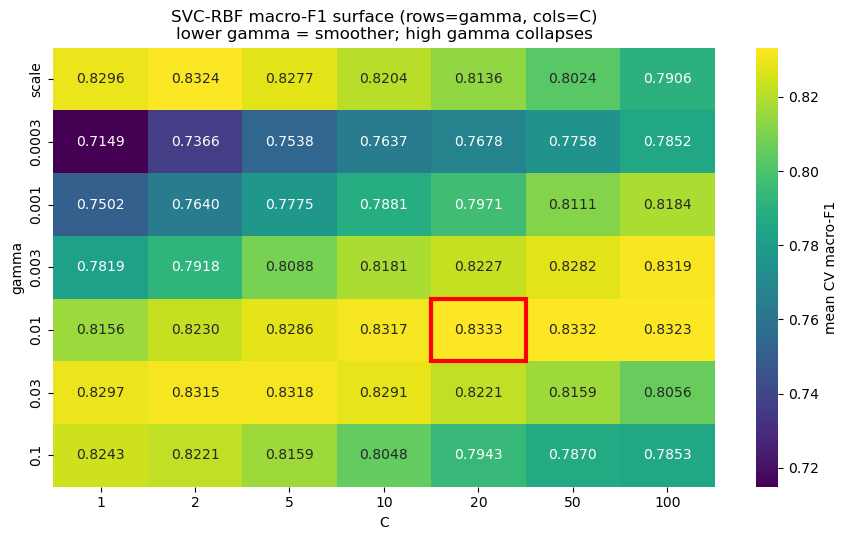

Red box = best cell. Watch macro-F1 fall as gamma rises toward 0.1 (overfitting onset).


In [3]:
# HEATMAP of mean macro-F1 across the C x gamma grid -> SEE the performance surface.
res["gamma_str"] = res["param_clf__gamma"].astype(str)
gamma_order = ["scale", "0.0003", "0.001", "0.003", "0.01", "0.03", "0.1"]
C_order = [1, 2, 5, 10, 20, 50, 100]
pivot = (res.pivot_table(index="gamma_str", columns="param_clf__C", values="mean_test_score")
            .reindex(index=gamma_order, columns=C_order))

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="viridis", ax=ax,
            cbar_kws={"label": "mean CV macro-F1"})
ax.set_title("SVC-RBF macro-F1 surface (rows=gamma, cols=C)\nlower gamma = smoother; high gamma collapses")
ax.set_xlabel("C"); ax.set_ylabel("gamma")
# mark the best cell
by, bx = gamma_order.index(str(best["clf__gamma"])), C_order.index(best["clf__C"])
ax.add_patch(plt.Rectangle((bx, by), 1, 1, fill=False, edgecolor="red", lw=3))
plt.tight_layout(); plt.show()
print("Red box = best cell. Watch macro-F1 fall as gamma rises toward 0.1 (overfitting onset).")

In [4]:
# TRAIN vs CV for the best config -> expose overfitting (wide gap = memorizing).
best_svc_kw = {"C": best["clf__C"],
               "gamma": best["clf__gamma"] if best["clf__gamma"] != "scale" else "scale"}
def f_best_svc_fast():  return svc_pipe(probability=False, **best_svc_kw)

best_run = eval_full(f_best_svc_fast, f"Best-grid SVC {best_svc_kw}")
train_pipe = f_best_svc_fast(); train_pipe.fit(X[model_features], y)
train_f1 = f1_score(y, train_pipe.predict(X[model_features]), average="macro")
print(f"Best-grid SVC: train macro-F1 {train_f1:.4f} vs CV {best_run['mean']:.4f}  "
      f"(gap {train_f1-best_run['mean']:+.4f}; large gap = overfitting)")

Best-grid SVC {'C': 20, 'gamma': 0.01} macro-F1 = 0.8333 +/- 0.0079   stage2-F1 = 0.7866  (5s)


Best-grid SVC: train macro-F1 0.8675 vs CV 0.8333  (gap +0.0343; large gap = overfitting)


## 3. Compare: best-grid SVC vs current-best SVC (γ=0.01) vs default SVC

Is the new optimum a real step up, just a neighbor of `gamma=0.01`, or effectively the same? We
score all three solo on the same folds.

In [5]:
def f_cur_svc_fast(): return svc_pipe(probability=False, C=20, gamma=0.01)
def f_def_svc_fast(): return svc_pipe(probability=False)   # C=1, gamma="scale"

cur_svc = eval_full(f_cur_svc_fast, "SVC current best (C=20, g=0.01)")
def_svc = eval_full(f_def_svc_fast, "SVC default (C=1, scale)")
print(f"\nBest-grid {best_run['mean']:.4f} | current(0.01) {cur_svc['mean']:.4f} | "
      f"default {def_svc['mean']:.4f}")
print(f"Best-grid vs current(0.01): {best_run['mean']-cur_svc['mean']:+.4f}")
same_as_001 = (best["clf__gamma"] == 0.01)
print("NOTE: best gamma == 0.01 -> the corrected grid (which searched BELOW 0.01) CONFIRMS 0.01."
      if same_as_001 else
      f"NOTE: best gamma = {best['clf__gamma']} differs from 0.01 -> a new optimum to test in the stack.")

SVC current best (C=20, g=0.01)    macro-F1 = 0.8333 +/- 0.0079   stage2-F1 = 0.7866  (5s)


SVC default (C=1, scale)           macro-F1 = 0.8296 +/- 0.0087   stage2-F1 = 0.7809  (6s)

Best-grid 0.8333 | current(0.01) 0.8333 | default 0.8296
Best-grid vs current(0.01): +0.0000
NOTE: best gamma == 0.01 -> the corrected grid (which searched BELOW 0.01) CONFIRMS 0.01.


## 4. Put the best-grid SVC into the stack

Stack = CatBoost + XGBoost + **best-grid SVC** → LogReg meta (internal `cv=5`, `predict_proba`).
We also re-evaluate the **current-best stack** (SVC C=20, γ=0.01) in this same run for an exact
same-fold comparison. The best-grid SVC is rebuilt with `probability=True` for stacking.

> Slow cells: each stack fits SVC many times via the internal CV. Let them run.

In [6]:
def f_cat():  return Pipeline([("impute", SimpleImputer(strategy="median")),
                               ("scale",  StandardScaler()),
                               ("clf",    CatBoostClassifier(iterations=600, learning_rate=0.05,
                                          depth=6, random_state=RANDOM_STATE, verbose=0,
                                          allow_writing_files=False))])
def f_xgb():  return Pipeline([("impute", SimpleImputer(strategy="median")),
                               ("scale",  StandardScaler()),
                               ("clf",    XGBClassifier(n_estimators=400, learning_rate=0.05,
                                          max_depth=6, subsample=0.9, colsample_bytree=0.9,
                                          random_state=RANDOM_STATE, eval_metric="mlogloss",
                                          n_jobs=-1, tree_method="hist"))])
def f_best_svc_proba(): return svc_pipe(probability=True, **best_svc_kw)
def f_cur_svc_proba():  return svc_pipe(probability=True, C=20, gamma=0.01)

def make_stack(svc_factory):
    return StackingClassifier(
        estimators=[("catboost", f_cat()), ("xgboost", f_xgb()), ("svc_rbf", svc_factory())],
        final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        cv=5, stack_method="predict_proba", n_jobs=-1)

stack_cur  = eval_full(lambda: make_stack(f_cur_svc_proba),  "Stack CURRENT (SVC g=0.01)")
stack_best = eval_full(lambda: make_stack(f_best_svc_proba), "Stack BEST-GRID SVC")

Stack CURRENT (SVC g=0.01)         macro-F1 = 0.8330 +/- 0.0071   stage2-F1 = 0.7844  (64s)


Stack BEST-GRID SVC                macro-F1 = 0.8330 +/- 0.0071   stage2-F1 = 0.7844  (61s)


## 5. Honesty check

Two conditions for a *clean* win:
1. The best-grid stack beats the current-best stack by **more than one fold std (~0.005–0.007)**.
2. It does so **without widening the std** — a higher mean bought with a *wider* std is a **worse
   leaderboard bet**, because a noisier CV transfers less reliably (tight std is exactly why the
   champion carried cleanly to Kaggle). We state this trade explicitly.

In [7]:
rows = [("SVC default solo", def_svc), ("SVC current(0.01) solo", cur_svc),
        ("SVC best-grid solo", best_run),
        ("Stack CURRENT (g=0.01)", stack_cur), ("Stack BEST-GRID", stack_best)]
board = (pd.DataFrame([{"config": n, "macro_f1": r["mean"], "std": r["std"],
                        "stage2_f1": r["stage2_f1"]} for n, r in rows])
           .sort_values("macro_f1", ascending=False).reset_index(drop=True))
print(board.round(4).to_string(index=False))

d_mean = stack_best["mean"] - stack_cur["mean"]
wider  = stack_best["std"] > stack_cur["std"]
beats_noise = d_mean > stack_cur["std"]
CLEAN_WIN = beats_noise and not wider

print(f"\nStack BEST-GRID {stack_best['mean']:.4f} +/- {stack_best['std']:.4f}  vs  "
      f"CURRENT {stack_cur['mean']:.4f} +/- {stack_cur['std']:.4f}")
print(f"delta mean = {d_mean:+.4f} (need > +{stack_cur['std']:.4f})   "
      f"std {'WIDER' if wider else 'same/tighter'} ({stack_best['std']:.4f} vs {stack_cur['std']:.4f})")
print(f"stage-2 F1: current {stack_cur['stage2_f1']:.3f} -> best-grid {stack_best['stage2_f1']:.3f} "
      f"(delta {stack_best['stage2_f1']-stack_cur['stage2_f1']:+.3f})")
if CLEAN_WIN:
    print("=> CLEAN WIN: beats noise AND does not widen std.")
elif beats_noise and wider:
    print("=> Higher mean but WIDER std -> worse leaderboard bet. Not a clean win.")
else:
    print("=> TIE within noise -> gamma=0.01 stands as the optimum.")

                config  macro_f1    std  stage2_f1
SVC current(0.01) solo    0.8333 0.0079     0.7866
    SVC best-grid solo    0.8333 0.0079     0.7866
Stack CURRENT (g=0.01)    0.8330 0.0071     0.7844
       Stack BEST-GRID    0.8330 0.0071     0.7844
      SVC default solo    0.8296 0.0087     0.7809

Stack BEST-GRID 0.8330 +/- 0.0071  vs  CURRENT 0.8330 +/- 0.0071
delta mean = +0.0000 (need > +0.0071)   std same/tighter (0.0071 vs 0.0071)
stage-2 F1: current 0.784 -> best-grid 0.784 (delta +0.000)
=> TIE within noise -> gamma=0.01 stands as the optimum.


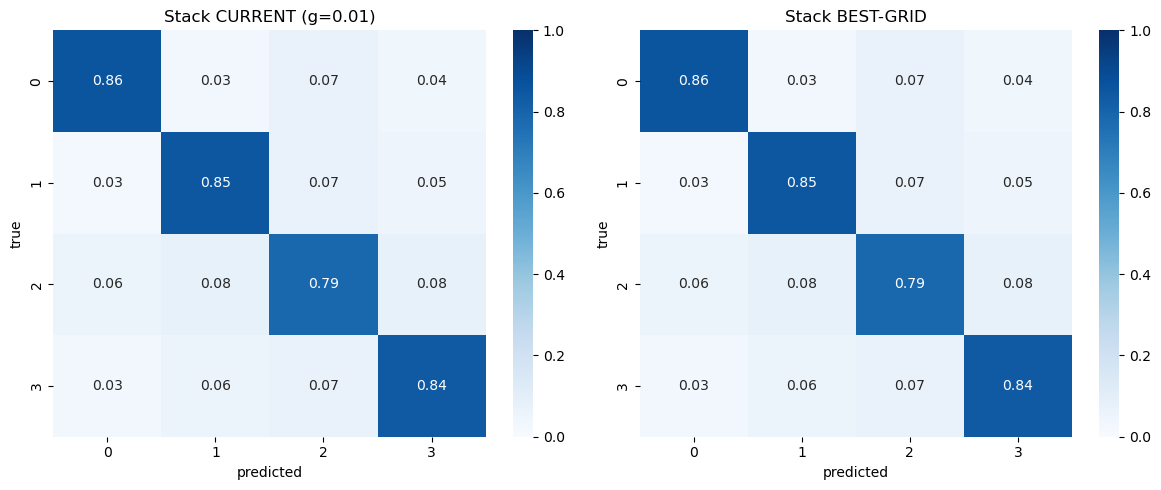

stage2->stage3 confusion: current 7.9% -> best-grid 7.9%


In [8]:
# Bottleneck confusion comparison (leakage-free OOF).
def norm_cm(oof):
    cm = confusion_matrix(y, oof, labels=classes); return cm / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, run, tag in [(axes[0], stack_cur, "Stack CURRENT (g=0.01)"),
                     (axes[1], stack_best, "Stack BEST-GRID")]:
    sns.heatmap(norm_cm(run["oof"]), annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(tag); ax.set_xlabel("predicted"); ax.set_ylabel("true")
plt.tight_layout(); plt.show()
r2, c3 = classes.index(2), classes.index(3)
print(f"stage2->stage3 confusion: current {norm_cm(stack_cur['oof'])[r2,c3]*100:.1f}% -> "
      f"best-grid {norm_cm(stack_best['oof'])[r2,c3]*100:.1f}%")

## 6. Verdict + (only on a clean win) build `submission_svcgrid.csv`

If the best-grid stack is a **clean win** (beats noise *and* doesn't widen std), we retrain it on
all data and write **`submission_svcgrid.csv`** with full sanity checks — never touching
`submission.csv`. Otherwise we conclude `gamma=0.01` was the true optimum (now confirmed over a
grid that explicitly searched *below* it) and the 0.84552 model stands.

In [9]:
if CLEAN_WIN:
    print(f"CLEAN WIN -> building submission_svcgrid.csv with best SVC {best_svc_kw}\n")
    test_ids = test_df["id"].copy()
    X_test = test_df.drop(columns=["id"]).copy()
    X_test[FLAG_COL] = X_test["eog_burst_index"].isna().astype(int)
    X_test = X_test[model_features]
    assert list(X_test.columns) == list(model_features), "column mismatch!"

    final = make_stack(f_best_svc_proba); final.fit(X[model_features], y)
    pred = np.asarray(final.predict(X_test)).ravel().astype(int)

    sample_cols = ["id", TARGET]
    for s in ["sample_submission.csv", "submission.csv"]:
        if os.path.exists(s):
            sample_cols = list(pd.read_csv(s, nrows=1).columns); break
    sub = pd.DataFrame({sample_cols[0]: test_ids.values, sample_cols[1]: pred})[sample_cols]

    ok = True
    c1 = len(sub) == len(test_df);                                  ok &= c1
    print(f"[{'PASS' if c1 else 'FAIL'}] 5000 rows: {len(sub)}")
    c2 = sub[sample_cols[1]].isna().sum() == 0;                     ok &= c2
    print(f"[{'PASS' if c2 else 'FAIL'}] no NaN predictions")
    c3 = set(sub[sample_cols[1]].unique()).issubset({0,1,2,3});     ok &= c3
    print(f"[{'PASS' if c3 else 'FAIL'}] integer labels {{0,1,2,3}}: {sorted(sub[sample_cols[1]].unique())}")
    dist = sub[sample_cols[1]].value_counts(normalize=True).sort_index()
    c4 = (dist >= 0.05).all();                                      ok &= c4
    print(f"[{'PASS' if c4 else 'FAIL'}] every class >= 5%:\n{(dist*100).round(1)}")
    c5 = list(sub.columns) == sample_cols;                          ok &= c5
    print(f"[{'PASS' if c5 else 'FAIL'}] columns == {sample_cols}")
    if ok:
        sub.to_csv("submission_svcgrid.csv", index=False)
        print("\nAll checks passed -> wrote submission_svcgrid.csv (submission.csv untouched).")
        print(sub.head().to_string(index=False))
    else:
        print("\nSanity checks FAILED -> NOT writing submission_svcgrid.csv.")
else:
    print("Not a clean win -> NOT building a submission. gamma=0.01 confirmed as the optimum; "
          "the current 0.84552 model stands. submission.csv untouched.")

Not a clean win -> NOT building a submission. gamma=0.01 confirmed as the optimum; the current 0.84552 model stands. submission.csv untouched.


## 7. Takeaway

- The **heatmap** shows the macro-F1 surface: a broad plateau at **small gamma** and a collapse as
  gamma climbs toward 0.1 — visual proof that this problem wants smooth kernels and that
  `gamma ≥ 1` would have been a trap.
- By searching **below** 0.01 (down to 0.0003), we tested the boundary-edge hypothesis directly.
  The verdict cell states whether a lower gamma genuinely beat 0.01 **without widening the std**, or
  whether **0.01 was the true optimum all along** — now confirmed over a properly designed grid.
- If nothing cleanly wins, that's a *useful* result: it closes the SVC-tuning question, and the
  0.84552 model stands. Future gains would need new geometry or the macro-F1 threshold lever, not
  more SVC tuning.

> Discipline held: macro-F1 (never accuracy) for all selection; every transformer fit inside its
> CV; the final fit (only on a clean win) trains on all-train and merely applies to test;
> `submission.csv` is never overwritten — only `submission_svcgrid.csv` is ever written.